# Eksplorasi Hasil Baseline YOLOv8s — Deteksi Helm Pengendara Motor

Notebook ini memuat model terlatih (`best.pt`), menampilkan metrik test, dan memvisualisasikan prediksi pada gambar test secara **inline**.

Sesuai `CLAUDE.md`: notebook hanya untuk eksplorasi; logika reusable diimpor dari `src/`.

Run: `experiments/helm_yolov8s_roboflow_20260611`

## 1. Setup & cek lingkungan

In [1]:
import sys
from pathlib import Path

# Cari root repo (folder yang punya configs/) lalu daftarkan ke sys.path
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'configs').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
print('Repo root:', REPO_ROOT)

from src.env import print_env  # util reusable dari src/
_ = print_env()

Repo root: /home/bdo/code/jupyter-code/foldersr/work/project-cv


ENVIRONMENT
  python          : 3.12.13
  platform        : Linux-6.8.0-124-generic-x86_64-with-glibc2.35
  cuda_available  : True
  device          : cuda:0
  gpu_name        : NVIDIA GeForce RTX 4090
  torch           : 2.8.0+cu128
  cuda            : 12.8
  ultralytics     : 8.4.65


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

RUN_DIR = REPO_ROOT / 'experiments' / 'helm_yolov8s_roboflow_20260611'
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
TEST_IMAGES = REPO_ROOT / 'data' / 'helmet-roboflow' / 'test' / 'images'
print('Checkpoint ada:', BEST_PT.exists())

Checkpoint ada: True


## 2. Metrik final di split test

In [3]:
metrics = json.loads((RUN_DIR / 'metrics.json').read_text())
pd.DataFrame([metrics]).T.rename(columns={0: 'nilai'})

,nilai
mAP50,0.960412
mAP50_95,0.688984
precision,0.957140
recall,0.940769
fps,295.929916


## 3. Grafik training (kurva loss & metrik per epoch)

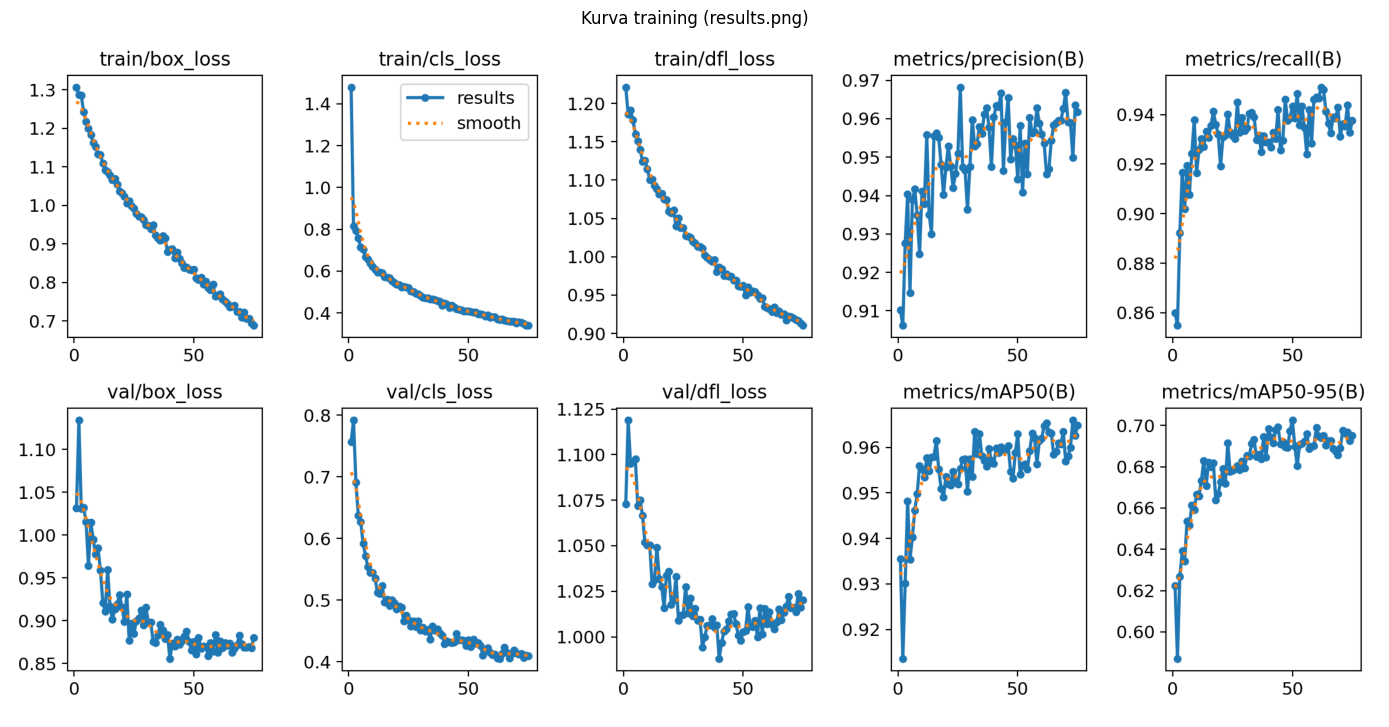

In [4]:
import matplotlib.image as mpimg

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(mpimg.imread(RUN_DIR / 'results.png'))
ax.axis('off')
ax.set_title('Kurva training (results.png)')
plt.tight_layout(); plt.show()

## 4. Muat model & jalankan inferensi pada gambar test

In [5]:
model = YOLO(str(BEST_PT))

# Ambil 6 gambar test pertama
sample = sorted(TEST_IMAGES.glob('*.jpg'))[:6]
results = model.predict(source=[str(p) for p in sample], imgsz=1280, conf=0.25, verbose=False)
print(f'{len(results)} gambar diproses')

6 gambar diproses


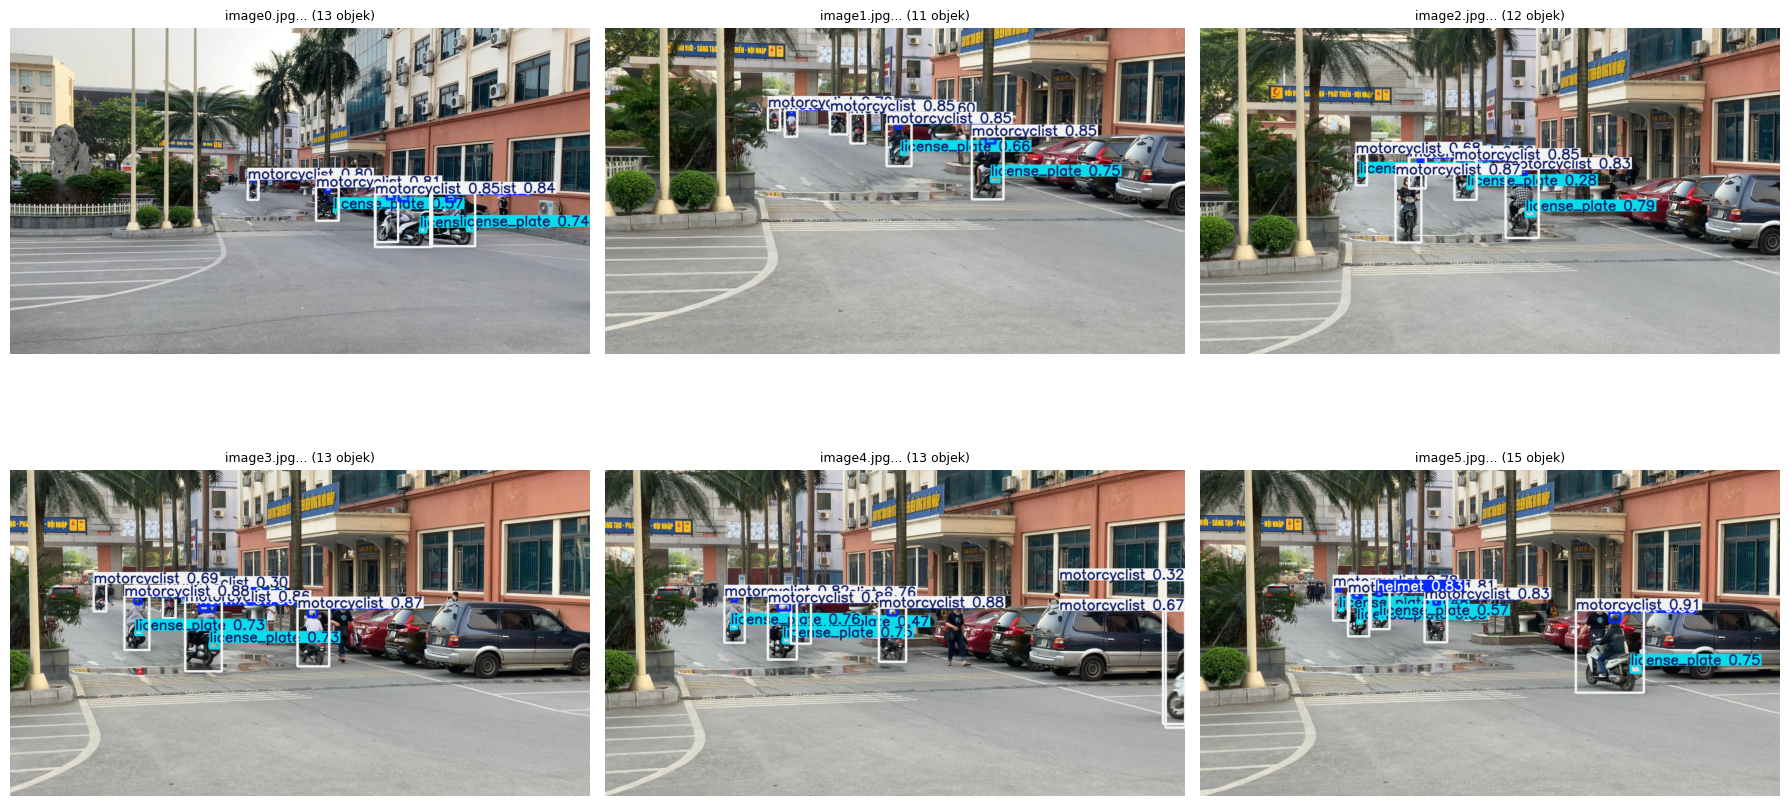

In [6]:
# Tampilkan prediksi (bounding box) inline
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, r in zip(axes.ravel(), results):
    im = r.plot()              # numpy BGR dengan box tergambar
    ax.imshow(im[..., ::-1])   # BGR -> RGB
    n = len(r.boxes)
    ax.set_title(f'{Path(r.path).name[:18]}... ({n} objek)', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Ringkasan deteksi per gambar

In [7]:
names = model.names
rows = []
for r in results:
    counts = {}
    for c in r.boxes.cls.tolist():
        label = names[int(c)]
        counts[label] = counts.get(label, 0) + 1
    rows.append({'gambar': Path(r.path).name[:24], **counts})
pd.DataFrame(rows).fillna(0)

,gambar,motorcyclist,helmet,license_plate
0,image0.jpg,5,5,3
1,image1.jpg,6,3,2
2,image2.jpg,5,4,3
3,image3.jpg,5,6,2
4,image4.jpg,6,4,3
5,image5.jpg,5,6,4


## 6. Langkah berikutnya

- Ablation: latih **YOLO11 / RT-DETR** (config baru, dataset sama) lalu bandingkan di sini.
- Uji generalisasi ke gambar CCTV Indonesia.
- Reproduksi pipeline multi-task + tracking (HELMET dataset).